In [1]:
# ============================================================
# Mining Reliability — Executive Insights Visualisations (Python)
# Source: African Mining Equipment Failure.csv
# Charts:
#  1) Pareto-style cost concentration by equipment type (+ downtime)
#  2) Severity vs sensor warnings: stacked contribution + any-alert rate
#  3) Maintenance strategy frontier: cost vs downtime (size = production loss)
# ============================================================


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import FuncFormatter


In [3]:
# ----------------------------
# 0) Load data
# ----------------------------
# Update path if needed
path = "African Mining Equipment Failure.csv"
df = pd.read_csv(path)


In [4]:
# ----------------------------
# 1) Clean / standardise types
# ----------------------------
# Normalise column names (optional but helps)
df.columns = [c.strip() for c in df.columns]

# Convert booleans stored as strings to 0/1
def to_bool01(s):
    if pd.isna(s):
        return np.nan
    if isinstance(s, (bool, np.bool_)):
        return int(s)
    s = str(s).strip().lower()
    if s in ["true", "1", "yes", "y", "t"]:
        return 1
    if s in ["false", "0", "no", "n", "f"]:
        return 0
    return np.nan

bool_cols = ["was_scheduled", "oil_analysis_flag", "vibration_flag", "temperature_flag"]
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].apply(to_bool01)

# Convert numeric columns safely
num_cols = ["downtime_hours", "repair_cost_usd", "production_loss_tonnes", "operating_hours", "days_since_last_service", "model_year"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Parse dates if present
if "event_date" in df.columns:
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")

# Basic filtering: ignore rows missing key IDs/types where needed
df_valid = df.copy()

# ----------------------------
# Helper formatters
# ----------------------------
def money(x, pos):
    # $ with commas; compact millions for readability if large
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    return f"${x:,.0f}"

def hours_fmt(x, pos):
    if abs(x) >= 1_000:
        return f"{x:,.0f}h"
    return f"{x:.0f}h"



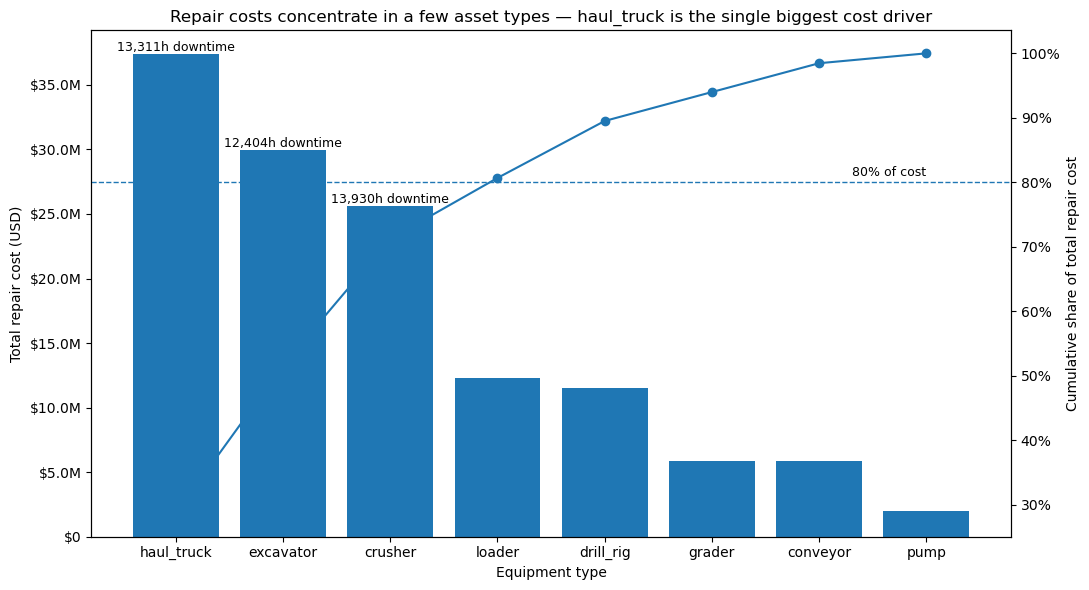

In [5]:
# ============================================================
# INSIGHT 1 — Cost & Downtime Concentration by Equipment Type
# (Pareto bar + cumulative line; annotations for top drivers)
# ============================================================

# Aggregate like your SQL output
eq_agg = (
    df_valid.groupby("equipment_type", dropna=False)
    .agg(
        event_count=("record_id", "count") if "record_id" in df_valid.columns else ("equipment_id", "count"),
        total_downtime_hours=("downtime_hours", "sum"),
        total_repair_cost_usd=("repair_cost_usd", "sum"),
        total_production_loss_tonnes=("production_loss_tonnes", "sum"),
    )
    .reset_index()
)

eq_agg = eq_agg.dropna(subset=["equipment_type"])
eq_agg = eq_agg.sort_values("total_repair_cost_usd", ascending=False)

# Compute cumulative share for Pareto line
total_cost = eq_agg["total_repair_cost_usd"].sum()
eq_agg["cost_share"] = eq_agg["total_repair_cost_usd"] / total_cost
eq_agg["cum_cost_share"] = eq_agg["cost_share"].cumsum()

# Plot
fig, ax1 = plt.subplots(figsize=(11, 6))

# Bars: total repair cost
ax1.bar(eq_agg["equipment_type"], eq_agg["total_repair_cost_usd"])
ax1.yaxis.set_major_formatter(FuncFormatter(money))
ax1.set_ylabel("Total repair cost (USD)")
ax1.set_xlabel("Equipment type")
ax1.tick_params(axis="x", rotation=0)

# Second axis: cumulative % line (Pareto)
ax2 = ax1.twinx()
ax2.plot(eq_agg["equipment_type"], eq_agg["cum_cost_share"], marker="o")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel("Cumulative share of total repair cost")

# Add an insight-driven title
top = eq_agg.iloc[0]
title = (
    f"Repair costs concentrate in a few asset types — {top['equipment_type']} is the single biggest cost driver"
)
plt.title(title)

# Annotate top 2–3 bars with downtime context
top_n_annotate = min(3, len(eq_agg))
for i in range(top_n_annotate):
    r = eq_agg.iloc[i]
    ax1.text(
        i,
        r["total_repair_cost_usd"],
        f"{r['total_downtime_hours']:,.0f}h downtime",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Add a reference line at 80% cumulative share if it helps
ax2.axhline(0.8, linestyle="--", linewidth=1)
ax2.text(len(eq_agg)-1, 0.805, "80% of cost", ha="right", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

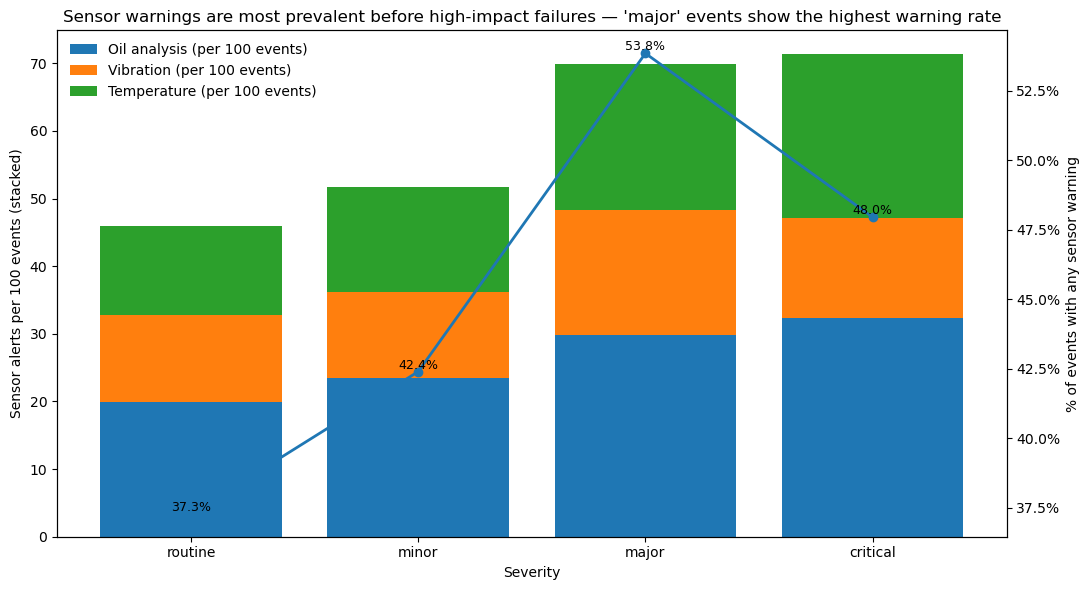

In [6]:
# ============================================================
# INSIGHT 2 — Severity & Sensor Warnings
# A) % with ANY alert (clean executive signal)
# B) Composition of alerts (oil/vibration/temp) as stacked contributions
# ============================================================

sev = df_valid.dropna(subset=["severity"]).copy()

# Ensure flags exist
for c in ["oil_analysis_flag", "vibration_flag", "temperature_flag"]:
    if c not in sev.columns:
        sev[c] = 0

sev["any_alert"] = (
    (sev["oil_analysis_flag"].fillna(0).astype(int) == 1) |
    (sev["vibration_flag"].fillna(0).astype(int) == 1) |
    (sev["temperature_flag"].fillna(0).astype(int) == 1)
).astype(int)

sev_agg = (
    sev.groupby("severity")
    .agg(
        event_count=("severity", "count"),
        oil_alerts=("oil_analysis_flag", "sum"),
        vibration_alerts=("vibration_flag", "sum"),
        temperature_alerts=("temperature_flag", "sum"),
        any_alerts=("any_alert", "sum"),
    )
    .reset_index()
)

sev_agg["pct_with_any_sensor_alert"] = 100.0 * sev_agg["any_alerts"] / sev_agg["event_count"]

# Try to order like your screenshot (routine, minor, major, critical)
severity_order = ["routine", "minor", "major", "critical"]
sev_agg["severity"] = sev_agg["severity"].astype(str).str.lower()
sev_agg["severity"] = pd.Categorical(sev_agg["severity"], categories=severity_order, ordered=True)
sev_agg = sev_agg.sort_values("severity")

# Stacked "contribution" bars: alerts per 100 events (keeps comparability)
sev_agg["oil_per_100"] = 100.0 * sev_agg["oil_alerts"] / sev_agg["event_count"]
sev_agg["vib_per_100"] = 100.0 * sev_agg["vibration_alerts"] / sev_agg["event_count"]
sev_agg["temp_per_100"] = 100.0 * sev_agg["temperature_alerts"] / sev_agg["event_count"]

x = np.arange(len(sev_agg))

fig, ax1 = plt.subplots(figsize=(11, 6))

# Stacked bars: per-100-event alert rates by sensor type
ax1.bar(x, sev_agg["oil_per_100"], label="Oil analysis (per 100 events)")
ax1.bar(x, sev_agg["vib_per_100"], bottom=sev_agg["oil_per_100"], label="Vibration (per 100 events)")
ax1.bar(
    x,
    sev_agg["temp_per_100"],
    bottom=sev_agg["oil_per_100"] + sev_agg["vib_per_100"],
    label="Temperature (per 100 events)"
)

ax1.set_xticks(x)
ax1.set_xticklabels([str(s) for s in sev_agg["severity"]])
ax1.set_ylabel("Sensor alerts per 100 events (stacked)")
ax1.set_xlabel("Severity")

# Overlay line: % with any alert (executive summary metric)
ax2 = ax1.twinx()
ax2.plot(x, sev_agg["pct_with_any_sensor_alert"], marker="o", linewidth=2)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylabel("% of events with any sensor warning")

# Insight-driven title (based on your pattern: major has the highest % in your screenshot)
max_row = sev_agg.loc[sev_agg["pct_with_any_sensor_alert"].idxmax()]
plt.title(
    f"Sensor warnings are most prevalent before high-impact failures — '{max_row['severity']}' events show the highest warning rate"
)

# Annotate the line values for clarity
for i, pct in enumerate(sev_agg["pct_with_any_sensor_alert"]):
    ax2.text(i, pct, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

ax1.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


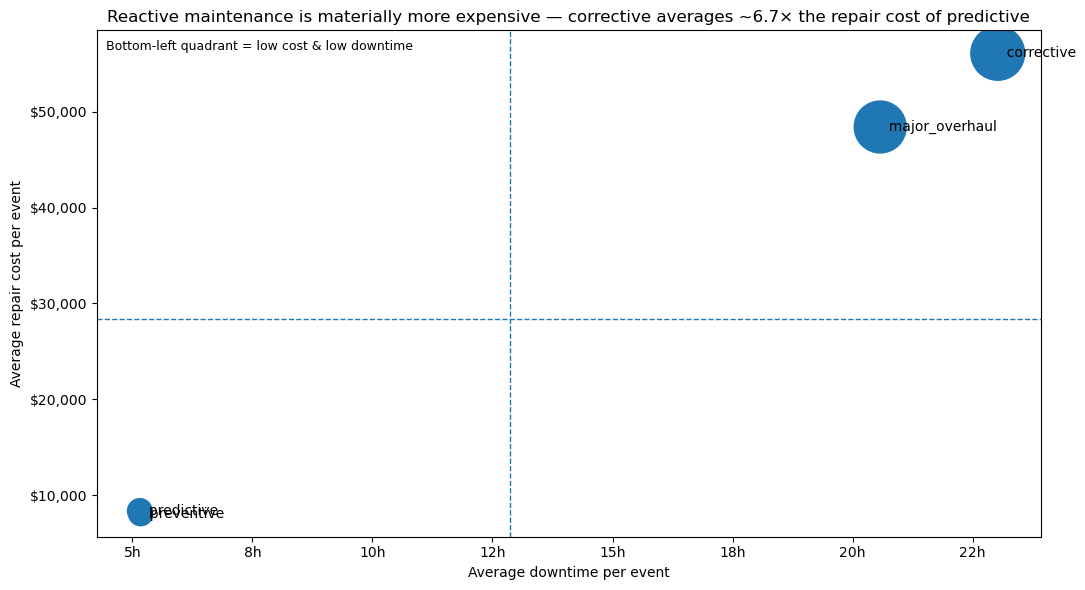

In [7]:
# ============================================================
# INSIGHT 3 — Maintenance Strategy Frontier
# Scatter: avg repair cost vs avg downtime
# Bubble size: avg production loss (tonnes)
# (This shows a clear separation between reactive vs proactive strategies)
# ============================================================

mt = df_valid.dropna(subset=["maintenance_type"]).copy()

mt_agg = (
    mt.groupby("maintenance_type")
    .agg(
        avg_downtime_hours=("downtime_hours", "mean"),
        avg_repair_cost_usd=("repair_cost_usd", "mean"),
        avg_production_loss_tonnes=("production_loss_tonnes", "mean"),
        n=("maintenance_type", "count"),
    )
    .reset_index()
)

# Bubble sizing: scale to look good
sizes = mt_agg["avg_production_loss_tonnes"].fillna(0)
# Avoid all-zero sizes
sizes = (sizes - sizes.min()) / (sizes.max() - sizes.min() + 1e-9)
sizes = 300 + sizes * 1200

fig, ax = plt.subplots(figsize=(11, 6))

sc = ax.scatter(
    mt_agg["avg_downtime_hours"],
    mt_agg["avg_repair_cost_usd"],
    s=sizes
)

ax.xaxis.set_major_formatter(FuncFormatter(hours_fmt))
ax.yaxis.set_major_formatter(FuncFormatter(money))

ax.set_xlabel("Average downtime per event")
ax.set_ylabel("Average repair cost per event")

# Label each point (maintenance type)
for _, r in mt_agg.iterrows():
    ax.text(
        r["avg_downtime_hours"],
        r["avg_repair_cost_usd"],
        f"  {r['maintenance_type']}",
        va="center",
        fontsize=10
    )

# Identify the "best" (low cost + low downtime) region visually
ax.axvline(mt_agg["avg_downtime_hours"].median(), linestyle="--", linewidth=1)
ax.axhline(mt_agg["avg_repair_cost_usd"].median(), linestyle="--", linewidth=1)
ax.text(
    0.01,
    0.98,
    "Bottom-left quadrant = low cost & low downtime",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

# Insight-driven title (your screenshot shows corrective/major_overhaul much worse than predictive/preventive)
# We'll compute a ratio to phrase the insight without hardcoding.
def safe_ratio(a, b):
    return float(a) / float(b) if (b is not None and b != 0 and not pd.isna(b)) else np.nan

row_corrective = mt_agg[mt_agg["maintenance_type"].astype(str).str.lower() == "corrective"]
row_predictive = mt_agg[mt_agg["maintenance_type"].astype(str).str.lower() == "predictive"]

if len(row_corrective) and len(row_predictive):
    c_cost = row_corrective["avg_repair_cost_usd"].iloc[0]
    p_cost = row_predictive["avg_repair_cost_usd"].iloc[0]
    ratio = safe_ratio(c_cost, p_cost)
    title = f"Reactive maintenance is materially more expensive — corrective averages ~{ratio:.1f}× the repair cost of predictive"
else:
    title = "Reactive maintenance clusters at higher cost and downtime — proactive strategies sit in the low-impact frontier"

plt.title(title)

plt.tight_layout()
plt.show()


In [8]:


# ============================================================
# Optional: print the summary tables used for the charts
# (useful for writing your report narrative)
# ============================================================

print("\n=== Table A: Cost & downtime by equipment type (sorted by repair cost) ===")
display(eq_agg)

print("\n=== Table B: Sensor alerts vs severity ===")
display(sev_agg[["severity","event_count","oil_alerts","vibration_alerts","temperature_alerts","pct_with_any_sensor_alert"]])

print("\n=== Table C: Avg downtime & cost by maintenance type ===")
display(mt_agg.sort_values("avg_repair_cost_usd", ascending=False))


=== Table A: Cost & downtime by equipment type (sorted by repair cost) ===


,equipment_type,event_count,total_downtime_hours,total_repair_cost_usd,total_production_loss_tonnes,cost_share,cum_cost_share
5,haul_truck,1287,13310.6,37364308.27,1498377.0,0.286686,0.286686
3,excavator,756,12404.5,29926903.17,1868816.0,0.229621,0.516307
1,crusher,518,13930.4,25584805.68,3039566.0,0.196305,0.712612
6,loader,574,6790.5,12281227.46,505954.0,0.094230,0.806842
2,drill_rig,603,4659.6,11510846.21,174727.0,0.088320,0.895162
4,grader,389,3844.4,5840907.54,57927.0,0.044816,0.939977
0,conveyor,600,3033.3,5827338.87,1142572.0,0.044712,0.984689
7,pump,273,1406.1,1995531.36,107509.0,0.015311,1.000000



=== Table B: Sensor alerts vs severity ===


,severity,event_count,oil_alerts,vibration_alerts,temperature_alerts,pct_with_any_sensor_alert
3,routine,2183,434,283,286,37.288136
2,minor,1427,335,182,220,42.396636
1,major,1146,341,213,247,53.839442
0,critical,244,79,36,59,47.950820



=== Table C: Avg downtime & cost by maintenance type ===


,maintenance_type,avg_downtime_hours,avg_repair_cost_usd,avg_production_loss_tonnes,n
0,corrective,23.024254,56091.192471,3202.045396,1542
1,major_overhaul,20.576154,48410.090769,2988.148718,390
2,predictive,5.153384,8349.929413,766.653895,783
3,preventive,5.171204,8061.846670,740.580306,2285


/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_20806/1943680918.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(g1p["equipment_type"], rotation=0)


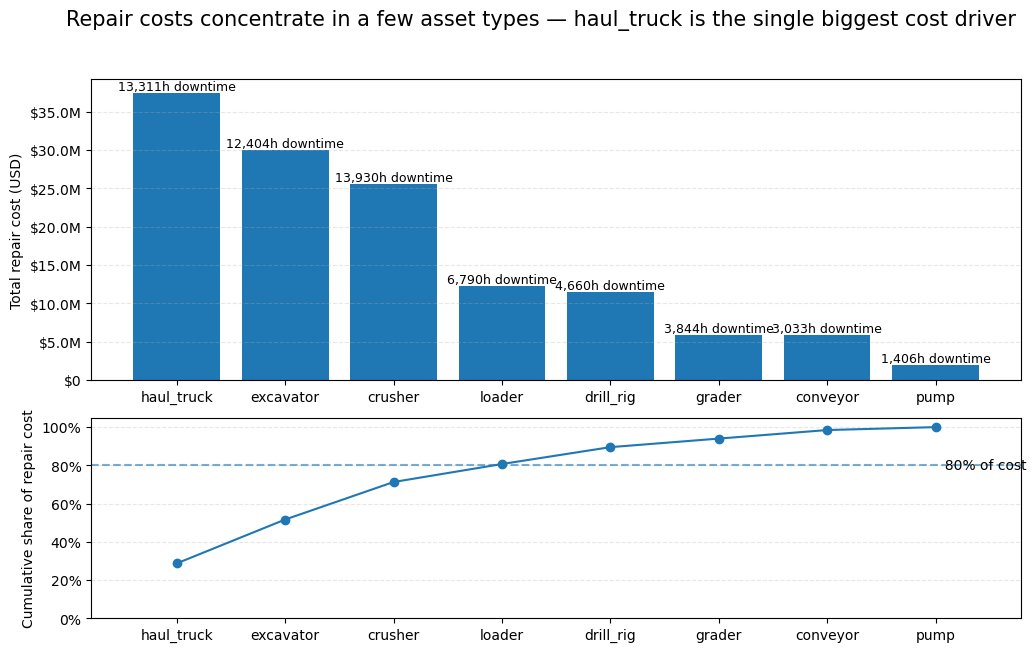

/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_20806/1943680918.py:139: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g2 = (df2.groupby("severity")
/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_20806/1943680918.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g2_any = df2.groupby("severity").agg(pct_any_alert=("any_alert", "mean")).reset_index()


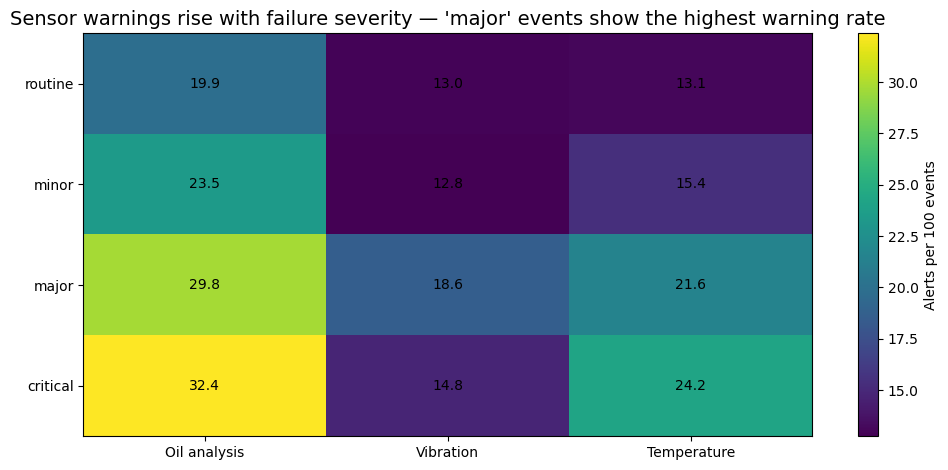

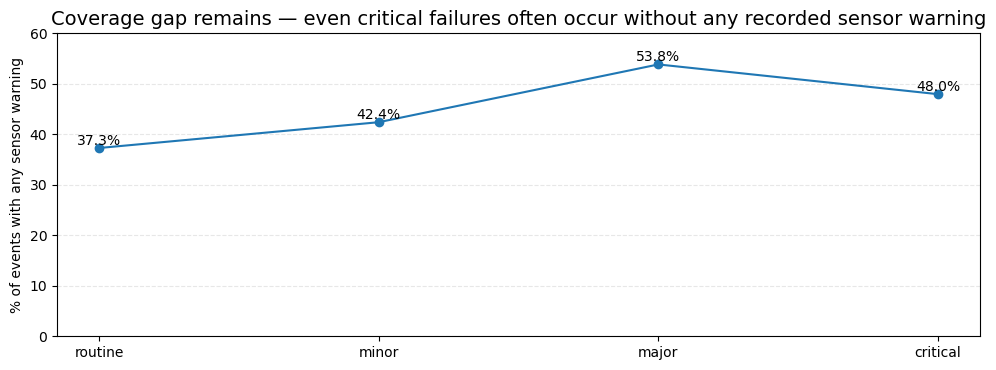

/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_20806/1943680918.py:207: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g3 = (df3.groupby("maintenance_type")


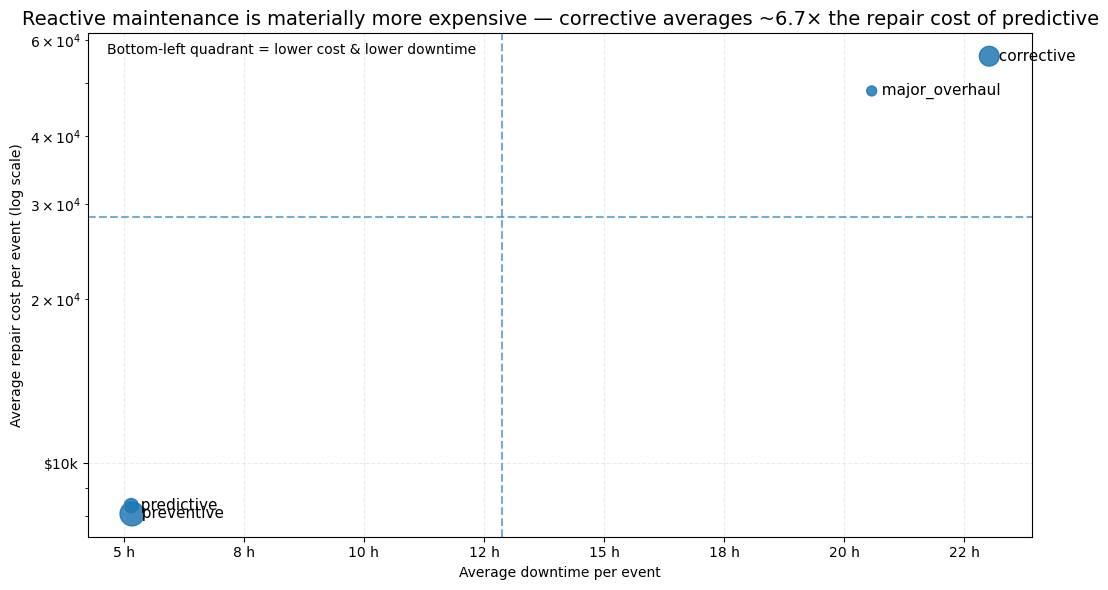

In [11]:
# ============================================================
# Mining Reliability – Executive Charts (readability-first)
# Uses matplotlib only (no seaborn). Insight-driven titles kept.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# -----------------------------
# 0) Load + light cleaning
# -----------------------------
CSV_PATH = "African Mining Equipment Failure.csv"  # <- update if needed
df = pd.read_csv(CSV_PATH)

# Standardize column names if needed (defensive)
df.columns = [c.strip() for c in df.columns]

# Expected columns based on your SQL outputs:
# equipment_type, severity, maintenance_type, downtime_hours, repair_cost_usd, production_loss_tonnes
# oil_analysis_flag, vibration_flag, temperature_flag
# If your file uses slightly different names, map them here:
rename_map = {
    "equipment type": "equipment_type",
    "repair cost usd": "repair_cost_usd",
    "production loss tonnes": "production_loss_tonnes",
    "downtime hours": "downtime_hours",
}
for k, v in rename_map.items():
    if k in df.columns and v not in df.columns:
        df = df.rename(columns={k: v})

# Coerce numerics
for col in ["downtime_hours", "repair_cost_usd", "production_loss_tonnes"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Coerce flags: True/False strings -> 1/0
flag_cols = ["oil_analysis_flag", "vibration_flag", "temperature_flag"]
for col in flag_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().map(
            {"true": 1, "false": 0, "1": 1, "0": 0, "nan": 0}
        ).fillna(0).astype(int)

# Standardize key categoricals
for col in ["equipment_type", "severity", "maintenance_type"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Helper formatters
def fmt_usd(x, _):
    if np.isnan(x): 
        return ""
    if abs(x) >= 1e6:
        return f"${x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:.0f}k"
    return f"${x:.0f}"

def fmt_hours(x, _):
    if np.isnan(x): 
        return ""
    if abs(x) >= 1e3:
        return f"{x/1e3:.1f}k h"
    return f"{x:.0f} h"

# ============================================================
# 1) Insight: Repair costs concentrate in a few asset types
#    "haul_truck is the single biggest cost driver"
#    Improved: split Pareto into two aligned panels (no 3 axes)
# ============================================================

# Aggregate by equipment type
g1 = (df.groupby("equipment_type", dropna=False)
        .agg(event_count=("equipment_type", "size"),
             total_downtime_hours=("downtime_hours", "sum"),
             total_repair_cost_usd=("repair_cost_usd", "sum"),
             total_production_loss_tonnes=("production_loss_tonnes", "sum"))
        .reset_index())

# Sort by repair cost desc
g1 = g1.sort_values("total_repair_cost_usd", ascending=False).reset_index(drop=True)
g1["cum_cost_share"] = g1["total_repair_cost_usd"].cumsum() / g1["total_repair_cost_usd"].sum()

# Pick top N for readability (keep all if you prefer)
TOP_N = 10
g1p = g1.head(TOP_N).copy()

# Title logic: highlight top driver
top_asset = g1p.loc[0, "equipment_type"]
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3, 2], hspace=0.15)

# Panel A: repair cost bars
ax1 = fig.add_subplot(gs[0])
ax1.bar(g1p["equipment_type"], g1p["total_repair_cost_usd"])
ax1.set_ylabel("Total repair cost (USD)")
ax1.yaxis.set_major_formatter(FuncFormatter(fmt_usd))
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.set_xticklabels(g1p["equipment_type"], rotation=0)

# Annotate downtime on bars (subtle, but valuable)
for i, row in g1p.iterrows():
    if pd.notna(row["total_downtime_hours"]):
        ax1.text(i, row["total_repair_cost_usd"], f"{row['total_downtime_hours']:,.0f}h downtime",
                 ha="center", va="bottom", fontsize=9)

# Panel B: cumulative cost share line (separate axis, separate panel)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(g1p["equipment_type"], g1p["cum_cost_share"], marker="o")
ax2.set_ylabel("Cumulative share of repair cost")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax2.grid(axis="y", linestyle="--", alpha=0.3)

# Reference line at 80%
ax2.axhline(0.80, linestyle="--", alpha=0.6)
ax2.text(len(g1p)-1, 0.80, "  80% of cost", va="center", fontsize=10)

fig.suptitle(
    f"Repair costs concentrate in a few asset types — {top_asset} is the single biggest cost driver",
    fontsize=15, y=0.98
)
plt.show()

# ============================================================
# 2) Insight: Sensor warnings vs severity
#    Improved: heatmap of alert rates + separate line for "any alert"
# ============================================================

# Order severities for narrative flow
severity_order = ["routine", "minor", "major", "critical"]
df2 = df[df["severity"].isin(severity_order)].copy()
df2["severity"] = pd.Categorical(df2["severity"], categories=severity_order, ordered=True)

# Compute rates per 100 events
g2 = (df2.groupby("severity")
        .agg(event_count=("severity", "size"),
             oil_alerts=("oil_analysis_flag", "sum"),
             vibration_alerts=("vibration_flag", "sum"),
             temperature_alerts=("temperature_flag", "sum"))
        .reset_index())

g2["oil_per_100"] = 100 * g2["oil_alerts"] / g2["event_count"]
g2["vibration_per_100"] = 100 * g2["vibration_alerts"] / g2["event_count"]
g2["temperature_per_100"] = 100 * g2["temperature_alerts"] / g2["event_count"]

# Any alert flag per event
df2["any_alert"] = ((df2["oil_analysis_flag"] == 1) |
                    (df2["vibration_flag"] == 1) |
                    (df2["temperature_flag"] == 1)).astype(int)
g2_any = df2.groupby("severity").agg(pct_any_alert=("any_alert", "mean")).reset_index()
g2 = g2.merge(g2_any, on="severity", how="left")
g2["pct_any_alert"] = 100 * g2["pct_any_alert"]

# Heatmap matrix
mat = g2.set_index("severity")[["oil_per_100", "vibration_per_100", "temperature_per_100"]].values
rows = g2["severity"].astype(str).tolist()
cols = ["Oil analysis", "Vibration", "Temperature"]

fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(mat, aspect="auto")

# Labels
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticks(np.arange(len(rows)))
ax.set_yticklabels(rows)
ax.set_title("Sensor warnings rise with failure severity — 'major' events show the highest warning rate", fontsize=14)

# Cell annotations
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.1f}", ha="center", va="center", fontsize=10)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Alerts per 100 events")

plt.tight_layout()
plt.show()

# Separate, simple line chart for "% with any alert"
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(g2["severity"].astype(str), g2["pct_any_alert"], marker="o")
ax.set_ylim(0, max(60, g2["pct_any_alert"].max() + 5))
ax.set_ylabel("% of events with any sensor warning")
ax.grid(axis="y", linestyle="--", alpha=0.3)

for i, v in enumerate(g2["pct_any_alert"]):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("Coverage gap remains — even critical failures often occur without any recorded sensor warning", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 3) Insight: Reactive maintenance is materially more expensive
#    Improved: quadrant bubble plot with log-scale for cost + clearer labeling
# ============================================================

maint_order = ["preventive", "predictive", "major_overhaul", "corrective"]
df3 = df[df["maintenance_type"].isin(maint_order)].copy()
df3["maintenance_type"] = pd.Categorical(df3["maintenance_type"], categories=maint_order, ordered=True)

g3 = (df3.groupby("maintenance_type")
        .agg(event_count=("maintenance_type", "size"),
             avg_downtime_hours=("downtime_hours", "mean"),
             avg_repair_cost_usd=("repair_cost_usd", "mean"),
             avg_production_loss_tonnes=("production_loss_tonnes", "mean"))
        .reset_index())

# Median lines for quadrant
x_med = g3["avg_downtime_hours"].median()
y_med = g3["avg_repair_cost_usd"].median()

# Bubble sizing by event volume
sizes = 300 * (g3["event_count"] / g3["event_count"].max()).clip(lower=0.15)

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(g3["avg_downtime_hours"], g3["avg_repair_cost_usd"], s=sizes, alpha=0.85)

# Log scale helps when cost ranges are wide (makes separation clearer)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_usd))
ax.xaxis.set_major_formatter(FuncFormatter(fmt_hours))

# Quadrant lines
ax.axvline(x_med, linestyle="--", alpha=0.6)
ax.axhline(y_med, linestyle="--", alpha=0.6)

# Direct labels (avoid legend lookup)
for _, r in g3.iterrows():
    ax.text(r["avg_downtime_hours"], r["avg_repair_cost_usd"], f"  {r['maintenance_type']}",
            va="center", fontsize=11)

# Ratio callout (corrective vs predictive) for the title
def safe_ratio(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b

corr = g3.loc[g3["maintenance_type"].astype(str) == "corrective", "avg_repair_cost_usd"]
pred = g3.loc[g3["maintenance_type"].astype(str) == "predictive", "avg_repair_cost_usd"]
ratio = safe_ratio(float(corr.iloc[0]) if len(corr) else np.nan, float(pred.iloc[0]) if len(pred) else np.nan)

title_ratio = f"~{ratio:.1f}×" if np.isfinite(ratio) else "materially higher"
ax.set_title(f"Reactive maintenance is materially more expensive — corrective averages {title_ratio} the repair cost of predictive", fontsize=14)

ax.set_xlabel("Average downtime per event")
ax.set_ylabel("Average repair cost per event (log scale)")
ax.grid(axis="both", linestyle="--", alpha=0.25)

# Quadrant annotation
ax.text(0.02, 0.98, "Bottom-left quadrant = lower cost & lower downtime",
        transform=ax.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()


/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_20806/1799153952.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(g1p["equipment_type"], rotation=0)


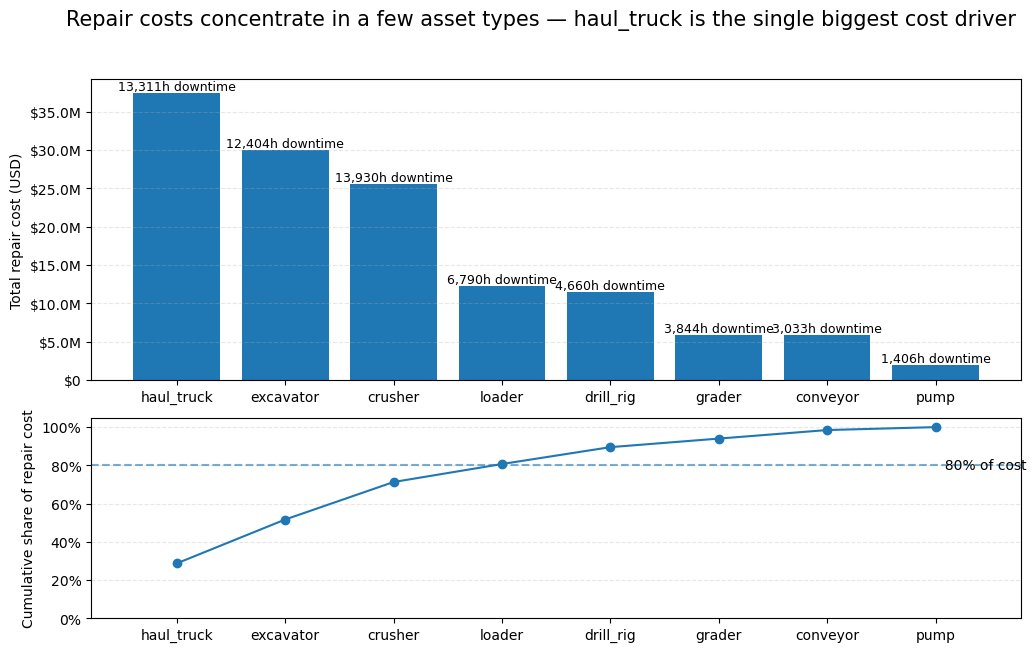

/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_20806/1799153952.py:139: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g2 = (df2.groupby("severity")
/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_20806/1799153952.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g2_any = df2.groupby("severity").agg(pct_any_alert=("any_alert", "mean")).reset_index()


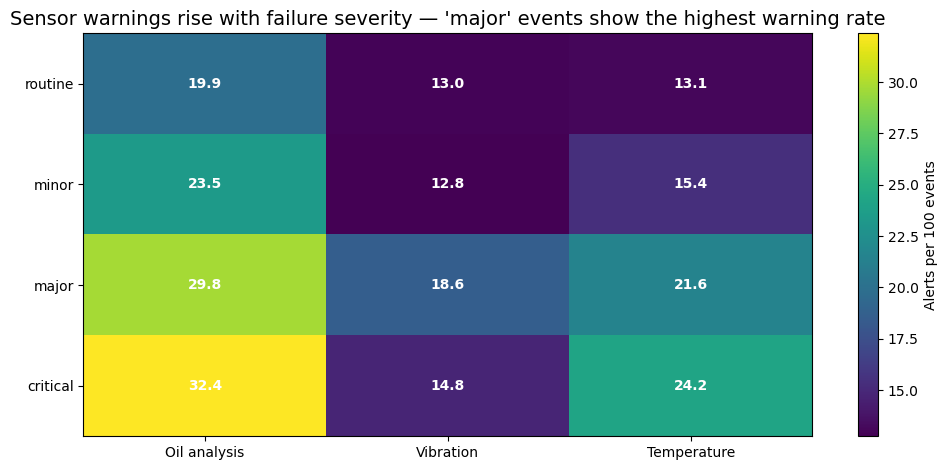

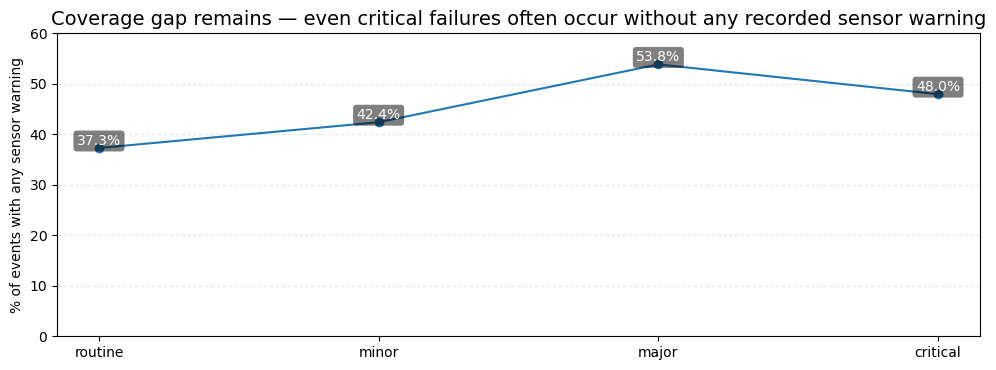

/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_20806/1799153952.py:221: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g3 = (df3.groupby("maintenance_type")


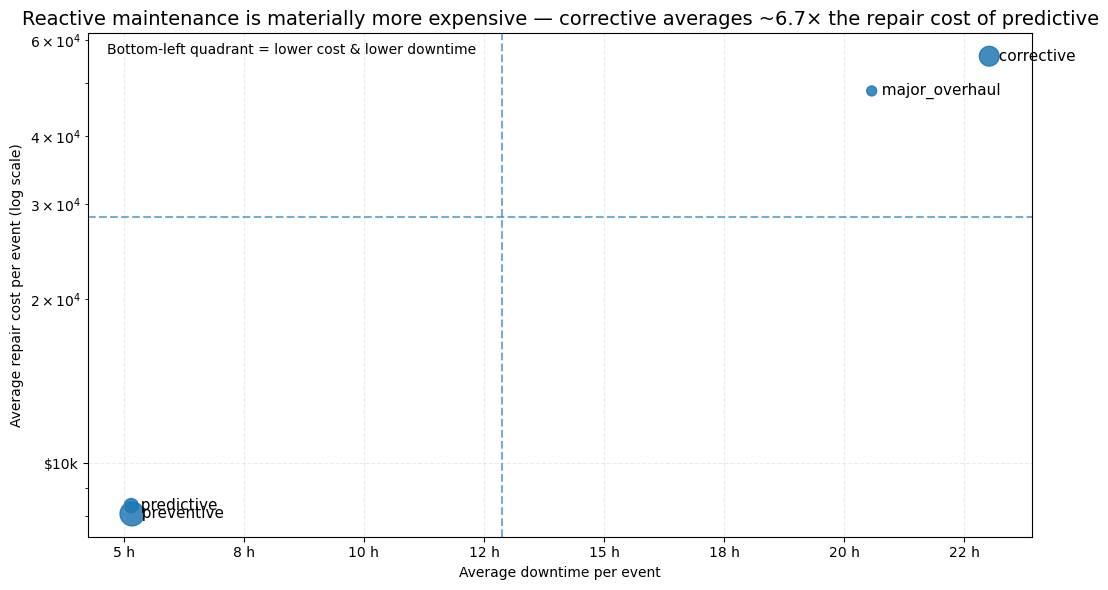

In [12]:
# ============================================================
# Mining Reliability – Executive Charts (readability-first)
# Uses matplotlib only (no seaborn). Insight-driven titles kept.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# -----------------------------
# 0) Load + light cleaning
# -----------------------------
CSV_PATH = "African Mining Equipment Failure.csv"  # <- update if needed
df = pd.read_csv(CSV_PATH)

# Standardize column names if needed (defensive)
df.columns = [c.strip() for c in df.columns]

# Expected columns based on your SQL outputs:
# equipment_type, severity, maintenance_type, downtime_hours, repair_cost_usd, production_loss_tonnes
# oil_analysis_flag, vibration_flag, temperature_flag
# If your file uses slightly different names, map them here:
rename_map = {
    "equipment type": "equipment_type",
    "repair cost usd": "repair_cost_usd",
    "production loss tonnes": "production_loss_tonnes",
    "downtime hours": "downtime_hours",
}
for k, v in rename_map.items():
    if k in df.columns and v not in df.columns:
        df = df.rename(columns={k: v})

# Coerce numerics
for col in ["downtime_hours", "repair_cost_usd", "production_loss_tonnes"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Coerce flags: True/False strings -> 1/0
flag_cols = ["oil_analysis_flag", "vibration_flag", "temperature_flag"]
for col in flag_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().map(
            {"true": 1, "false": 0, "1": 1, "0": 0, "nan": 0}
        ).fillna(0).astype(int)

# Standardize key categoricals
for col in ["equipment_type", "severity", "maintenance_type"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Helper formatters
def fmt_usd(x, _):
    if np.isnan(x): 
        return ""
    if abs(x) >= 1e6:
        return f"${x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:.0f}k"
    return f"${x:.0f}"

def fmt_hours(x, _):
    if np.isnan(x): 
        return ""
    if abs(x) >= 1e3:
        return f"{x/1e3:.1f}k h"
    return f"{x:.0f} h"

# ============================================================
# 1) Insight: Repair costs concentrate in a few asset types
#    "haul_truck is the single biggest cost driver"
#    Improved: split Pareto into two aligned panels (no 3 axes)
# ============================================================

# Aggregate by equipment type
g1 = (df.groupby("equipment_type", dropna=False)
        .agg(event_count=("equipment_type", "size"),
             total_downtime_hours=("downtime_hours", "sum"),
             total_repair_cost_usd=("repair_cost_usd", "sum"),
             total_production_loss_tonnes=("production_loss_tonnes", "sum"))
        .reset_index())

# Sort by repair cost desc
g1 = g1.sort_values("total_repair_cost_usd", ascending=False).reset_index(drop=True)
g1["cum_cost_share"] = g1["total_repair_cost_usd"].cumsum() / g1["total_repair_cost_usd"].sum()

# Pick top N for readability (keep all if you prefer)
TOP_N = 10
g1p = g1.head(TOP_N).copy()

# Title logic: highlight top driver
top_asset = g1p.loc[0, "equipment_type"]
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3, 2], hspace=0.15)

# Panel A: repair cost bars
ax1 = fig.add_subplot(gs[0])
ax1.bar(g1p["equipment_type"], g1p["total_repair_cost_usd"])
ax1.set_ylabel("Total repair cost (USD)")
ax1.yaxis.set_major_formatter(FuncFormatter(fmt_usd))
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.set_xticklabels(g1p["equipment_type"], rotation=0)

# Annotate downtime on bars (subtle, but valuable)
for i, row in g1p.iterrows():
    if pd.notna(row["total_downtime_hours"]):
        ax1.text(i, row["total_repair_cost_usd"], f"{row['total_downtime_hours']:,.0f}h downtime",
                 ha="center", va="bottom", fontsize=9)

# Panel B: cumulative cost share line (separate axis, separate panel)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(g1p["equipment_type"], g1p["cum_cost_share"], marker="o")
ax2.set_ylabel("Cumulative share of repair cost")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax2.grid(axis="y", linestyle="--", alpha=0.3)

# Reference line at 80%
ax2.axhline(0.80, linestyle="--", alpha=0.6)
ax2.text(len(g1p)-1, 0.80, "  80% of cost", va="center", fontsize=10)

fig.suptitle(
    f"Repair costs concentrate in a few asset types — {top_asset} is the single biggest cost driver",
    fontsize=15, y=0.98
)
plt.show()

# ============================================================
# 2) Insight: Sensor warnings vs severity
#    Improved: heatmap of alert rates + separate line for "any alert"
# ============================================================

# Order severities for narrative flow
severity_order = ["routine", "minor", "major", "critical"]
df2 = df[df["severity"].isin(severity_order)].copy()
df2["severity"] = pd.Categorical(df2["severity"], categories=severity_order, ordered=True)

# Compute rates per 100 events
g2 = (df2.groupby("severity")
        .agg(event_count=("severity", "size"),
             oil_alerts=("oil_analysis_flag", "sum"),
             vibration_alerts=("vibration_flag", "sum"),
             temperature_alerts=("temperature_flag", "sum"))
        .reset_index())

g2["oil_per_100"] = 100 * g2["oil_alerts"] / g2["event_count"]
g2["vibration_per_100"] = 100 * g2["vibration_alerts"] / g2["event_count"]
g2["temperature_per_100"] = 100 * g2["temperature_alerts"] / g2["event_count"]

# Any alert flag per event
df2["any_alert"] = ((df2["oil_analysis_flag"] == 1) |
                    (df2["vibration_flag"] == 1) |
                    (df2["temperature_flag"] == 1)).astype(int)
g2_any = df2.groupby("severity").agg(pct_any_alert=("any_alert", "mean")).reset_index()
g2 = g2.merge(g2_any, on="severity", how="left")
g2["pct_any_alert"] = 100 * g2["pct_any_alert"]

# Heatmap matrix
mat = g2.set_index("severity")[["oil_per_100", "vibration_per_100", "temperature_per_100"]].values
rows = g2["severity"].astype(str).tolist()
cols = ["Oil analysis", "Vibration", "Temperature"]

fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(mat, aspect="auto")

# Labels
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticks(np.arange(len(rows)))
ax.set_yticklabels(rows)
ax.set_title("Sensor warnings rise with failure severity — 'major' events show the highest warning rate", fontsize=14)

# Cell annotations (WHITE)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(
            j, i, f"{mat[i, j]:.1f}",
            ha="center", va="center",
            fontsize=10,
            color="white",
            fontweight="bold"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Alerts per 100 events")

plt.tight_layout()
plt.show()

# Separate, simple line chart for "% with any alert"
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(g2["severity"].astype(str), g2["pct_any_alert"], marker="o")
ax.set_ylim(0, max(60, g2["pct_any_alert"].max() + 5))
ax.set_ylabel("% of events with any sensor warning")
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Point labels (WHITE) — add a dark bbox so white text is readable
for i, v in enumerate(g2["pct_any_alert"]):
    ax.text(
        i, v, f"{v:.1f}%",
        ha="center", va="bottom",
        fontsize=10,
        color="white",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="black", alpha=0.5, edgecolor="none")
    )

ax.set_title("Coverage gap remains — even critical failures often occur without any recorded sensor warning", fontsize=14)
plt.tight_layout()
plt.show()


# ============================================================
# 3) Insight: Reactive maintenance is materially more expensive
#    Improved: quadrant bubble plot with log-scale for cost + clearer labeling
# ============================================================

maint_order = ["preventive", "predictive", "major_overhaul", "corrective"]
df3 = df[df["maintenance_type"].isin(maint_order)].copy()
df3["maintenance_type"] = pd.Categorical(df3["maintenance_type"], categories=maint_order, ordered=True)

g3 = (df3.groupby("maintenance_type")
        .agg(event_count=("maintenance_type", "size"),
             avg_downtime_hours=("downtime_hours", "mean"),
             avg_repair_cost_usd=("repair_cost_usd", "mean"),
             avg_production_loss_tonnes=("production_loss_tonnes", "mean"))
        .reset_index())

# Median lines for quadrant
x_med = g3["avg_downtime_hours"].median()
y_med = g3["avg_repair_cost_usd"].median()

# Bubble sizing by event volume
sizes = 300 * (g3["event_count"] / g3["event_count"].max()).clip(lower=0.15)

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(g3["avg_downtime_hours"], g3["avg_repair_cost_usd"], s=sizes, alpha=0.85)

# Log scale helps when cost ranges are wide (makes separation clearer)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_usd))
ax.xaxis.set_major_formatter(FuncFormatter(fmt_hours))

# Quadrant lines
ax.axvline(x_med, linestyle="--", alpha=0.6)
ax.axhline(y_med, linestyle="--", alpha=0.6)

# Direct labels (avoid legend lookup)
for _, r in g3.iterrows():
    ax.text(r["avg_downtime_hours"], r["avg_repair_cost_usd"], f"  {r['maintenance_type']}",
            va="center", fontsize=11)

# Ratio callout (corrective vs predictive) for the title
def safe_ratio(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b

corr = g3.loc[g3["maintenance_type"].astype(str) == "corrective", "avg_repair_cost_usd"]
pred = g3.loc[g3["maintenance_type"].astype(str) == "predictive", "avg_repair_cost_usd"]
ratio = safe_ratio(float(corr.iloc[0]) if len(corr) else np.nan, float(pred.iloc[0]) if len(pred) else np.nan)

title_ratio = f"~{ratio:.1f}×" if np.isfinite(ratio) else "materially higher"
ax.set_title(f"Reactive maintenance is materially more expensive — corrective averages {title_ratio} the repair cost of predictive", fontsize=14)

ax.set_xlabel("Average downtime per event")
ax.set_ylabel("Average repair cost per event (log scale)")
ax.grid(axis="both", linestyle="--", alpha=0.25)

# Quadrant annotation
ax.text(0.02, 0.98, "Bottom-left quadrant = lower cost & lower downtime",
        transform=ax.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()
